In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab_Notebooks/BI_lecture1

/content/drive/MyDrive/Colab_Notebooks/BI_lecture1


In [4]:
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

tar: ./root/.bashrc.biolab: file changed as we read it
tar: ./root/.condarc: file changed as we read it
tar: ./root/.profile: file changed as we read it
./
./root/
./root/.bashrc.biolab
./root/.bin.priority/
./root/.bin.priority/pip
./root/.bin.priority/pip2
./root/.bin.priority/pip3
./root/.condarc
./root/.profile
./root/.tmux.conf
tar: ./root/.tmux.conf: file changed as we read it
tar: ./root/.vimrc: file changed as we read it
tar: ./root: file changed as we read it
tar: .: file changed as we read it
./root/.vimrc
PREFIX=/root/conda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible 

In [5]:
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [6]:
!conda install -y bedtools bioawk samtools

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: | / - done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - bedtools
    - bioawk
    - samtools


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    bedtools-2.31.1            |       h13024bc_3         1.5 MB  bioconda
    bioawk-1.0                 |      h577a1d6_13         198 KB  bioconda
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    conda-26.3.2               |  py313h

In [7]:
%cd /content/drive/MyDrive/Colab_Notebooks/BI_lecture1/binfo1-work/

/content/drive/MyDrive/Colab_Notebooks/BI_lecture1/binfo1-work


In [8]:
!grep '	start_codon	.*	+	.*transcript_support_level "1"' ../binfo1-datapack1/gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-start.gtf
!head gencode-start.gtf

chr1	HAVANA	start_codon	4878137	4878139	.	+	0	ENSMUST00000134384.8
chr1	HAVANA	start_codon	4878137	4878139	.	+	0	ENSMUST00000027036.11
chr1	HAVANA	start_codon	4878137	4878139	.	+	0	ENSMUST00000150971.8
chr1	HAVANA	start_codon	4928137	4928139	.	+	0	ENSMUST00000081551.14
chr1	HAVANA	start_codon	5154674	5154676	.	+	0	ENSMUST00000044369.13
chr1	HAVANA	start_codon	5659272	5659274	.	+	0	ENSMUST00000160777.8
chr1	HAVANA	start_codon	5659272	5659274	.	+	0	ENSMUST00000027038.11
chr1	HAVANA	start_codon	6300227	6300229	.	+	0	ENSMUST00000027040.13
chr1	HAVANA	start_codon	6429555	6429557	.	+	0	ENSMUST00000133144.4
chr1	HAVANA	start_codon	6839122	6839124	.	+	0	ENSMUST00000140079.8


In [9]:
# 아래 공백 중 일부는 "탭(Tab)" 문자입니다. 입력하기 힘들 때는 텍스트 편집기에서 입력해서 복사&붙여넣기 하면 됩니다.
!grep '	exon	.*	+	' ../binfo1-datapack1/gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-plusexon.gtf
!head gencode-plusexon.gtf

chr1	HAVANA	exon	3143476	3144545	.	+	.	ENSMUST00000193812.2
chr1	ENSEMBL	exon	3172239	3172348	.	+	.	ENSMUST00000082908.3
chr1	HAVANA	exon	3322980	3323459	.	+	.	ENSMUST00000192857.2
chr1	HAVANA	exon	3536810	3536910	.	+	.	ENSMUST00000161581.2
chr1	HAVANA	exon	3583628	3583776	.	+	.	ENSMUST00000161581.2
chr1	HAVANA	exon	3602018	3602943	.	+	.	ENSMUST00000192183.2
chr1	HAVANA	exon	3750378	3752011	.	+	.	ENSMUST00000193244.2
chr1	HAVANA	exon	3822233	3824583	.	+	.	ENSMUST00000194454.2
chr1	HAVANA	exon	4566774	4569601	.	+	.	ENSMUST00000193450.2
chr1	HAVANA	exon	4567697	4567877	.	+	.	ENSMUST00000194935.2


In [10]:
# 아래 공백 중 일부는 "탭(Tab)" 문자입니다. 입력하기 힘들 때는 텍스트 편집기에서 입력해서 복사&붙여넣기 하면 됩니다.
!bedtools intersect -a gencode-start.gtf -b gencode-plusexon.gtf -wa -wb | \
 awk -F'	' -v OFS='	' '$9 == $18 { print $10, $13-1, $14, $18, $4-1, $16; }' | \
 sort -k1,1 -k2,3n -k4,4 > gencode-exons-containing-startcodon.bed
!head gencode-exons-containing-startcodon.bed; tail gencode-exons-containing-startcodon.bed

chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878052	4878205	ENSMUST00000150971.8	4878136	+
chr1	4928036	4928199	ENSMUST00000081551.14	4928136	+
chr1	5154639	5154786	ENSMUST00000044369.13	5154673	+
chr1	5659227	5659528	ENSMUST00000027038.11	5659271	+
chr1	5659257	5659528	ENSMUST00000160777.8	5659271	+
chr1	6300182	6300297	ENSMUST00000027040.13	6300226	+
chr1	6429441	6429738	ENSMUST00000133144.4	6429554	+
chr1	6839121	6839176	ENSMUST00000043578.13	6839121	+
chrY	80939672	80939804	ENSMUST00000185340.2	80939686	+
chrY	81470683	81470815	ENSMUST00000187135.2	81470697	+
chrY	82237903	82238035	ENSMUST00000185636.2	82237917	+
chrY	83043623	83043755	ENSMUST00000187165.2	83043637	+
chrY	84109956	84110088	ENSMUST00000185776.7	84109970	+
chrY	84759361	84759493	ENSMUST00000186110.2	84759375	+
chrY	86074448	86074580	ENSMUST00000188754.2	86074462	+
chrY	87129500	87129632	ENSMUST00000189543.7	87129514	+
chrY	87563647	87563779	ENSMUST0000

# Figure for siLuc

In [11]:
!(samtools view -H ../binfo1-datapack1/RPF-siLuc.bam; \
  samtools view -F20 ../binfo1-datapack1/RPF-siLuc.bam | \
  bioawk -c sam '{ if (length($seq) >= 25) print $0; }') | \
 samtools view -b -o filtered-RPF-siLuc.bam

samtools: /root/conda/bin/../lib/libtinfow.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libtinfow.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libtinfow.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncurses

In [12]:
!ls -al *RPF-siLuc.bam

-rw------- 1 root root  554373661 May 22 03:11 filtered-RPF-siLuc.bam
-rw------- 1 root root 1055123479 Apr 29 04:52 RPF-siLuc.bam


In [13]:
!bedtools genomecov -ibam filtered-RPF-siLuc.bam -bg -5 > fivepcounts-RPF-siLuc.bed
!head fivepcounts-RPF-siLuc.bed

chr1	3176534	3176535	1
chr1	3196256	3196257	1
chr1	3221526	3221527	1
chr1	3221542	3221543	2
chr1	3221545	3221546	3
chr1	3221546	3221547	2
chr1	3221548	3221550	1
chr1	3221571	3221572	1
chr1	3221897	3221898	1
chr1	3221994	3221995	1


In [14]:
!bedtools intersect -a fivepcounts-RPF-siLuc.bed -b gencode-exons-containing-startcodon.bed \
 -wa -wb -nonamecheck > fivepcounts-filtered-RPF-siLuc.txt
!head fivepcounts-filtered-RPF-siLuc.txt

chr1	4878048	4878049	1	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878048	4878049	1	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878077	4878078	1	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878077	4878078	1	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878077	4878078	1	chr1	4878052	4878205	ENSMUST00000150971.8	4878136	+
chr1	4878101	4878102	4	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878101	4878102	4	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+
chr1	4878101	4878102	4	chr1	4878052	4878205	ENSMUST00000150971.8	4878136	+
chr1	4878103	4878104	1	chr1	4878010	4878205	ENSMUST00000134384.8	4878136	+
chr1	4878103	4878104	1	chr1	4878045	4878205	ENSMUST00000027036.11	4878136	+


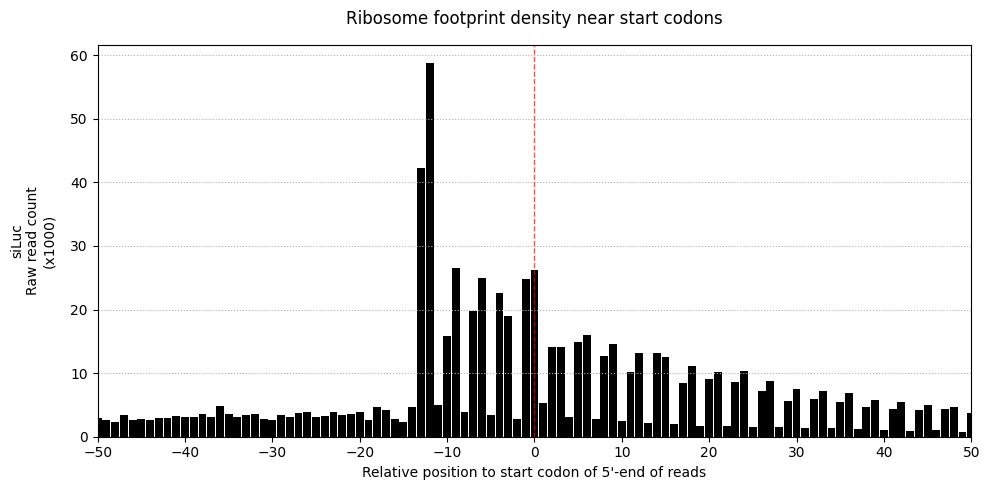

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 불러오기
counts = {}
with open('fivepcounts-filtered-RPF-siLuc.txt', 'r') as f:
    for line in f:
        fields = line.strip().split('\t')
        read_pos = int(fields[1])
        count = int(fields[3])
        start_codon_pos = int(fields[8])

        rel_pos = read_pos - start_codon_pos
        if -50 <= rel_pos <= 50:
            counts[rel_pos] = counts.get(rel_pos, 0) + count

df_plot = pd.DataFrame(list(counts.items()), columns=['rel_pos', 'count']).sort_values('rel_pos')

# 2. 시각화 (Figure S5A 스타일 재현)
plt.figure(figsize=(10, 5))

# Raw count를 1000으로 나누어 표시 (라벨의 x1000 반영)
plt.bar(df_plot['rel_pos'], df_plot['count'] / 1000, color='black', width=0.9)

# Start codon 위치 표시
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.title('Ribosome footprint density near start codons', fontsize=12, pad=15)
plt.xlabel("Relative position to start codon of 5'-end of reads", fontsize=10)
plt.ylabel('siLuc\nRaw read count\n(x1000)', fontsize=10, labelpad=10)

# X축 범위 및 틱 설정 (20nt 단위)
plt.xlim(-50, 50)
plt.xticks(np.arange(-50, 51, 10))

# 스타일 조정
plt.grid(axis='y', linestyle=':', alpha=1)
plt.tight_layout()

plt.show()

1. Start codon 주변 리보솜 분포(KDE) 분석 시작...
총 7343개의 스케일링된 샘플 포인트로 KDE를 생성합니다.


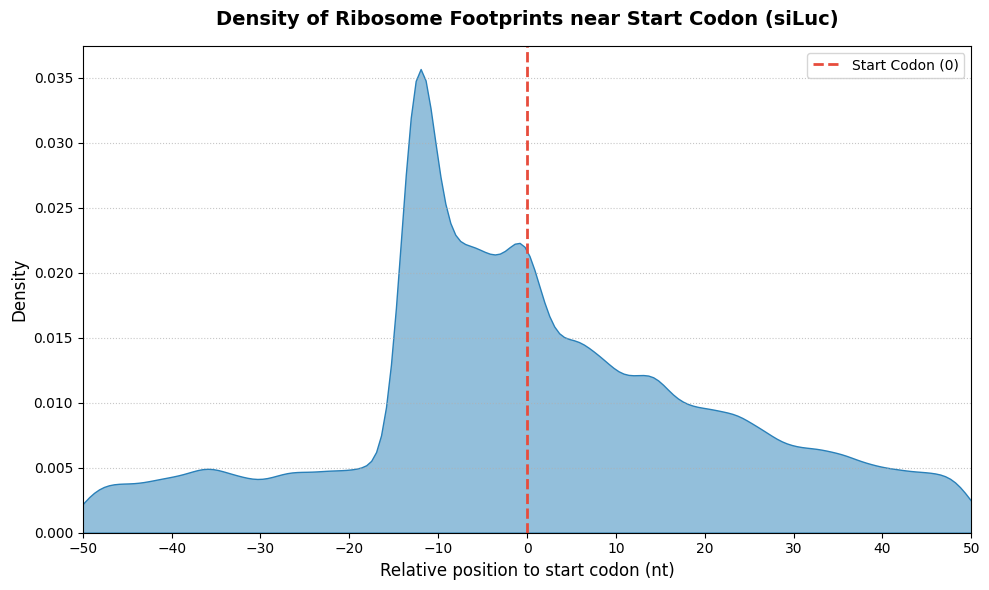

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("1. Start codon 주변 리보솜 분포(KDE) 분석 시작...")

scale_factor = 100
expanded_positions = []

for index, row in df_plot.iterrows():
    pos = int(row['rel_pos'])
    cnt = int(row['count'] / scale_factor) # 스케일링 적용
    if cnt > 0:
        expanded_positions.extend([pos] * cnt)

# 새로운 데이터프레임 생성
kde_data = pd.DataFrame({'rel_pos': expanded_positions})

print(f"총 {len(kde_data)}개의 스케일링된 샘플 포인트로 KDE를 생성합니다.")

# 2. 시각화 (KDE Plot)
fig, ax = plt.subplots(figsize=(10, 6))

# Seaborn을 사용하여 밀도 곡선 그리기
sns.kdeplot(data=kde_data, x='rel_pos', fill=True, color='#2980B9', alpha=0.5, ax=ax, bw_adjust=0.5)

# Start codon 위치 (x=0) 강조
ax.axvline(x=0, color='#E74C3C', linestyle='--', linewidth=2, label='Start Codon (0)')

# 꾸미기
ax.set_title('Density of Ribosome Footprints near Start Codon (siLuc)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Relative position to start codon (nt)", fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-50, 50)
ax.set_xticks(np.arange(-50, 51, 10))
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

# Figure for siLin28a

In [17]:
# 1. siLin28a BAM 파일에서 길이가 25 이상인 리드만 필터링
!(samtools view -H ../binfo1-datapack1/RPF-siLin28a.bam; \
  samtools view -F20 ../binfo1-datapack1/RPF-siLin28a.bam | \
  bioawk -c sam '{ if (length($seq) >= 25) print $0; }') | \
 samtools view -b -o filtered-RPF-siLin28a.bam

# 2. 5' end 위치 추출
!bedtools genomecov -ibam filtered-RPF-siLin28a.bam -bg -5 > fivepcounts-RPF-siLin28a.bed

# 3. Start codon 위치와 교집합(Intersect) 구하기
!bedtools intersect -a fivepcounts-RPF-siLin28a.bed -b gencode-exons-containing-startcodon.bed \
 -wa -wb -nonamecheck > fivepcounts-filtered-RPF-siLin28a.txt

!echo "✅ siLin28a 데이터 추출 완료!"

samtools: /root/conda/bin/../lib/libtinfow.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libtinfow.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libtinfow.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncurses

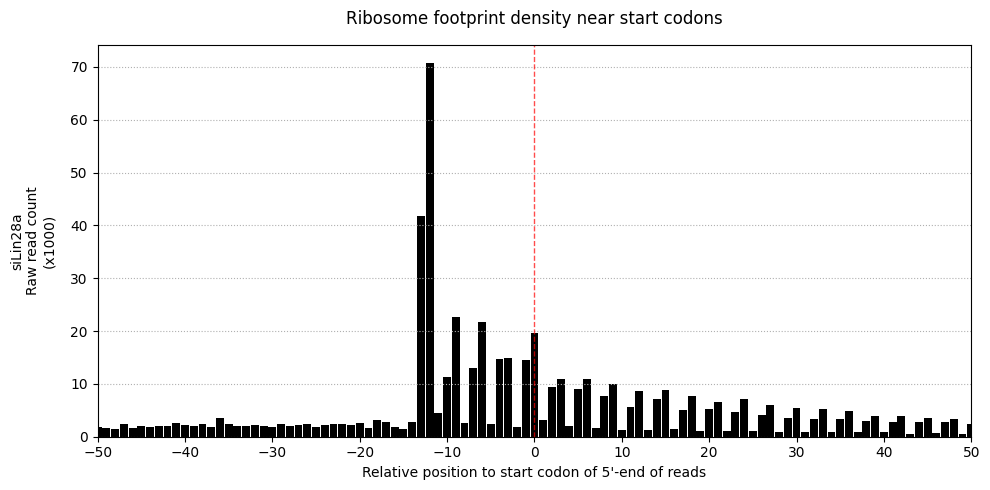

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 불러오기
counts = {}
with open('fivepcounts-filtered-RPF-siLin28a.txt', 'r') as f:
    for line in f:
        fields = line.strip().split('\t')
        read_pos = int(fields[1])
        count = int(fields[3])
        start_codon_pos = int(fields[8])

        rel_pos = read_pos - start_codon_pos
        if -50 <= rel_pos <= 50:
            counts[rel_pos] = counts.get(rel_pos, 0) + count

df_plot_lin28a = pd.DataFrame(list(counts.items()), columns=['rel_pos', 'count']).sort_values('rel_pos')

# 2. 시각화 (Figure S5A 스타일 재현)
plt.figure(figsize=(10, 5))

# Raw count를 1000으로 나누어 표시 (라벨의 x1000 반영)
plt.bar(df_plot_lin28a['rel_pos'], df_plot_lin28a['count'] / 1000, color='black', width=0.9)

# Start codon 위치 표시
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.title('Ribosome footprint density near start codons', fontsize=12, pad=15)
plt.xlabel("Relative position to start codon of 5'-end of reads", fontsize=10)
plt.ylabel('siLin28a\nRaw read count\n(x1000)', fontsize=10, labelpad=10)

# X축 범위 및 틱 설정 (20nt 단위)
plt.xlim(-50, 50)
plt.xticks(np.arange(-50, 51, 10))

# 스타일 조정
plt.grid(axis='y', linestyle=':', alpha=1)
plt.tight_layout()

plt.show()

1. Start codon 주변 리보솜 분포(KDE) 분석 시작...
총 5409개의 스케일링된 샘플 포인트로 KDE를 생성합니다.


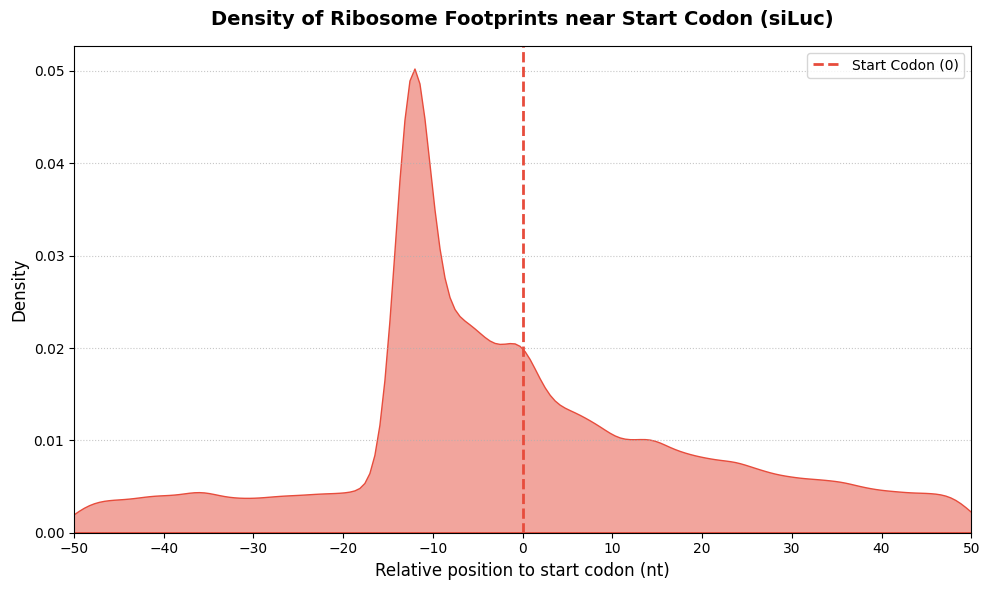

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("1. Start codon 주변 리보솜 분포(KDE) 분석 시작...")

scale_factor = 100
expanded_positions = []

for index, row in df_plot_lin28a.iterrows():
    pos = int(row['rel_pos'])
    cnt = int(row['count'] / scale_factor) # 스케일링 적용
    if cnt > 0:
        expanded_positions.extend([pos] * cnt)

# 새로운 데이터프레임 생성
kde_data = pd.DataFrame({'rel_pos': expanded_positions})

print(f"총 {len(kde_data)}개의 스케일링된 샘플 포인트로 KDE를 생성합니다.")

# 2. 시각화 (KDE Plot)
fig, ax = plt.subplots(figsize=(10, 6))

# Seaborn을 사용하여 밀도 곡선 그리기
sns.kdeplot(data=kde_data, x='rel_pos', fill=True, color='#E74C3C', alpha=0.5, ax=ax, bw_adjust=0.5)

# Start codon 위치 (x=0) 강조
ax.axvline(x=0, color='#E74C3C', linestyle='--', linewidth=2, label='Start Codon (0)')

# 꾸미기
ax.set_title('Density of Ribosome Footprints near Start Codon (siLuc)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Relative position to start codon (nt)", fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-50, 50)
ax.set_xticks(np.arange(-50, 51, 10))
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

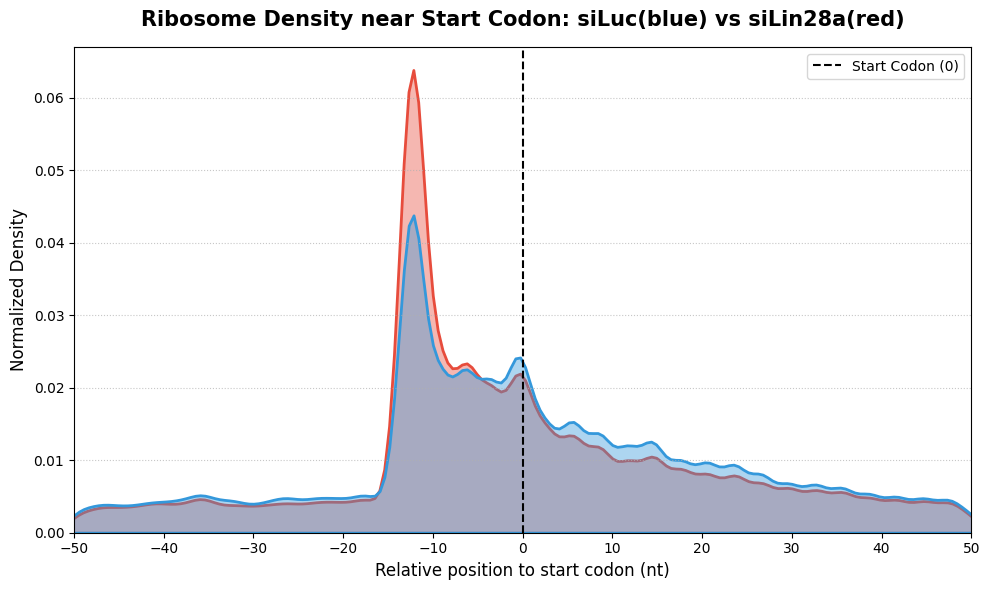

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 텍스트 파일에서 카운트 데이터를 읽어오는 함수
def get_rel_counts(filename):
    counts = {}
    with open(filename, 'r') as f:
        for line in f:
            fields = line.strip().split('\t')
            read_pos = int(fields[1])
            count = int(fields[3])
            start_codon_pos = int(fields[8])

            rel_pos = read_pos - start_codon_pos
            if -50 <= rel_pos <= 50:
                counts[rel_pos] = counts.get(rel_pos, 0) + count

    return pd.DataFrame(list(counts.items()), columns=['rel_pos', 'count']).sort_values('rel_pos')

# 두 파일 데이터 불러오기
df_luc = get_rel_counts('fivepcounts-filtered-RPF-siLuc.txt')
df_lin28a = get_rel_counts('fivepcounts-filtered-RPF-siLin28a.txt')

# 2. 밀도(KDE) 플롯을 위한 데이터 스케일링 전처리
scale_factor = 50
expanded_data = []
conditions = []

for index, row in df_luc.iterrows():
    cnt = int(row['count'] / scale_factor)
    if cnt > 0:
        expanded_data.extend([int(row['rel_pos'])] * cnt)
        conditions.extend(['Control (siLuc)'] * cnt)

for index, row in df_lin28a.iterrows():
    cnt = int(row['count'] / scale_factor)
    if cnt > 0:
        expanded_data.extend([int(row['rel_pos'])] * cnt)
        conditions.extend(['Lin28a KD (siLin28a)'] * cnt)

kde_df = pd.DataFrame({'rel_pos': expanded_data, 'Condition': conditions})

# 3. 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# KDE Plot
sns.kdeplot(
    data=kde_df, x='rel_pos', hue='Condition',
    fill=True, common_norm=False,
    palette={'Control (siLuc)': '#3498DB', 'Lin28a KD (siLin28a)': '#E74C3C'},
    alpha=0.4, linewidth=2, bw_adjust=0.4, ax=ax
)

# Start codon 위치 표시
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Start Codon (0)')

# 꾸미기
ax.set_title('Ribosome Density near Start Codon: siLuc(blue) vs siLin28a(red)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Relative position to start codon (nt)", fontsize=12)
ax.set_ylabel('Normalized Density', fontsize=12)
ax.set_xlim(-50, 50)
ax.set_xticks(np.arange(-50, 51, 10))
ax.grid(axis='y', linestyle=':', alpha=0.7)

# 범례 표시: sns.kdeplot의 hue와 ax.axvline의 label을 모두 포함합니다.
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# Reason
2주차 미션에서는 siLuc의 Start codon 주변 리보솜 분포만을 분석하였으나,
이번분석에서 siLin28a의 데이터를 추가로 추출하여 두 그룹 간의 리보솜 밀도 분포를 KDE를 이용해서 비교했습니다.
이를 통해 Lin28a 넉다운 전후로 번역 개시 위치 주변의 리보솜 밀도 양상이 어떻게 변화하는지 시각적으로 명확하게 대조할 수 있었습니다.

두 그룹 간의 리보솜 밀도 분포를 비교한 결과, siLuc 대비 siLin28a에서 start codon 직후 영역의 리보솜 밀도가 급격하게 상승하는 것을 확인했습니다.

siLuc에서는 LIN28A가 번역 개시를 방해하여 리보솜의 밀집도가 낮게 유지되지만, LIN28A가 제거되었을 때 억제되어 있던 번역이 폭발적으로 재개되면서 시작 코돈 주변으로 리보솜이 대거 동원됨을 시각적으로 증명합니다. 이는 "LIN28A가 특정 타겟 mRNA의 번역을 억제한다"는 논문의 핵심 결론과 완벽하게 일치하는 결과입니다.